In [1]:
import pandas as pd
df = pd.read_csv('../data/survey.csv')
print(df.shape)
df.head()

(1259, 27)


,Timestamp,Age,Gender,Country,state,self_employed,family_history,treatment,work_interfere,no_employees,...,leave,mental_health_consequence,phys_health_consequence,coworkers,supervisor,mental_health_interview,phys_health_interview,mental_vs_physical,obs_consequence,comments
0,2014-08-27 11:29:31,37,Female,United States,IL,NaN,No,Yes,Often,6-25,...,Somewhat easy,No,No,Some of them,Yes,No,Maybe,Yes,No,NaN
1,2014-08-27 11:29:37,44,M,United States,IN,NaN,No,No,Rarely,More than 1000,...,Don't know,Maybe,No,No,No,No,No,Don't know,No,NaN
2,2014-08-27 11:29:44,32,Male,Canada,NaN,NaN,No,No,Rarely,6-25,...,Somewhat difficult,No,No,Yes,Yes,Yes,Yes,No,No,NaN
3,2014-08-27 11:29:46,31,Male,United Kingdom,NaN,NaN,Yes,Yes,Often,26-100,...,Somewhat difficult,Yes,Yes,Some of them,No,Maybe,Maybe,No,Yes,NaN
4,2014-08-27 11:30:22,31,Male,United States,TX,NaN,No,No,Never,100-500,...,Don't know,No,No,Some of them,Yes,Yes,Yes,Don't know,No,NaN


In [2]:
print("Shape:", df.shape)
print("\nColumns:\n", df.columns.tolist())
print("\nDtypes:\n", df.dtypes)
print("\nNull counts:\n", df.isnull().sum().sort_values(ascending=False))
print("\nDescribe:\n", df.describe())

Shape: (1259, 27)

Columns:
 ['Timestamp', 'Age', 'Gender', 'Country', 'state', 'self_employed', 'family_history', 'treatment', 'work_interfere', 'no_employees', 'remote_work', 'tech_company', 'benefits', 'care_options', 'wellness_program', 'seek_help', 'anonymity', 'leave', 'mental_health_consequence', 'phys_health_consequence', 'coworkers', 'supervisor', 'mental_health_interview', 'phys_health_interview', 'mental_vs_physical', 'obs_consequence', 'comments']

Dtypes:
 Timestamp                      str
Age                          int64
Gender                         str
Country                        str
state                          str
self_employed                  str
family_history                 str
treatment                      str
work_interfere                 str
no_employees                   str
remote_work                    str
tech_company                   str
benefits                       str
care_options                   str
wellness_program               str
s

In [4]:
import matplotlib.pyplot as plt

Matplotlib is building the font cache; this may take a moment.


/opt/homebrew/lib/python3.11/site-packages/missingno/missingno.py:61: UserWarning: Plotting a sparkline on an existing axis is not currently supported. To remove this warning, set sparkline=False.
  warnings.warn(


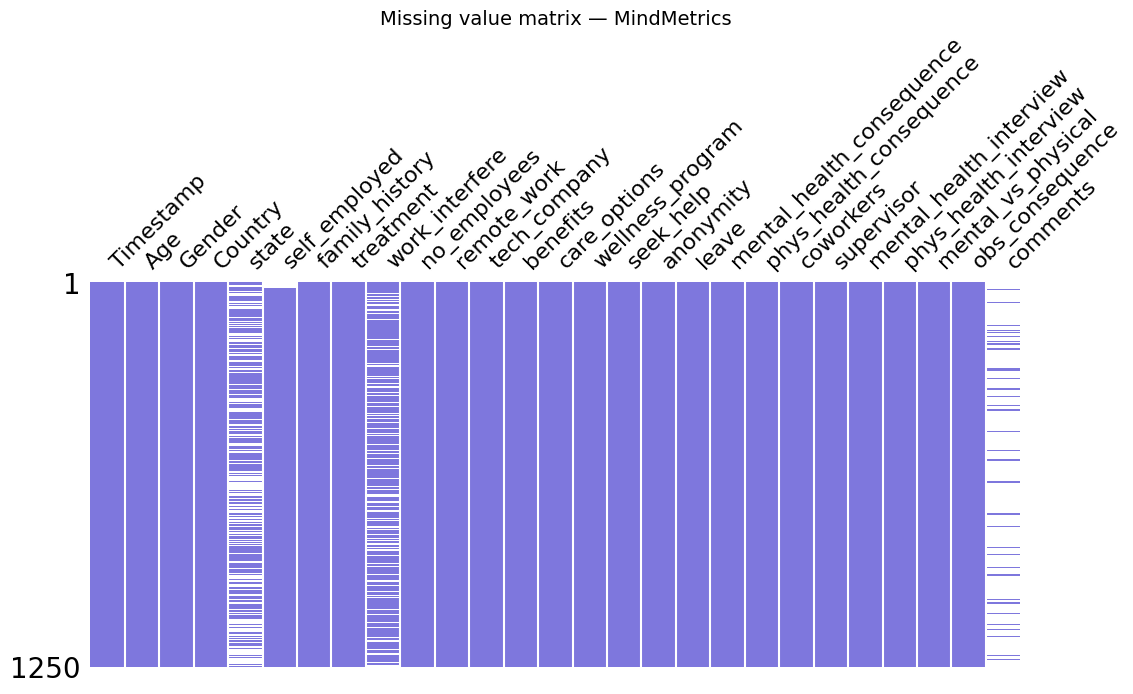

In [18]:

import missingno as msno

fig, ax = plt.subplots(figsize=(12, 5))
msno.matrix(df, ax=ax, color=(0.498, 0.467, 0.867))
plt.title('Missing value matrix — MindMetrics', fontsize=14)
plt.show()

#Comments column has 80% missing — will be excluded. self_employed has 1.4% missing — will impute with mode

In [22]:

# See the damage first
print("Age range before:", df['Age'].min(), "to", df['Age'].max())
print("Weird values:", df[df['Age'] < 18]['Age'].value_counts())


Age range before: 18 to 65
Weird values: Series([], Name: count, dtype: int64)


In [23]:
# Fix
df = df[(df['Age'] >= 18) & (df['Age'] <= 65)]
print("Age range after:", df['Age'].min(), "to", df['Age'].max())
print("Rows remaining:", df.shape[0])

Age range after: 18 to 65
Rows remaining: 1250


In [24]:
print(df['Gender'].unique())
print("\nTotal unique:", df['Gender'].nunique())

<StringArray>
[                                        'Female',
                                              'M',
                                           'Male',
                                           'male',
                                         'female',
                                              'm',
                                       'Male-ish',
                                          'maile',
                                   'Trans-female',
                                     'Cis Female',
                                              'F',
                          'something kinda male?',
                                       'Cis Male',
                                          'Woman',
                                              'f',
                                            'Mal',
                                     'Male (CIS)',
                                 'queer/she/they',
                                     'non-binary',
                 

In [25]:
male_vals = ['male','m','male ','maile','mal','man','make',
             'male (cis)','cis male','cis man','malr','mail',
             'msle','guy (-ish) ^_^']

female_vals = ['female','f','woman','female ','femail',
               'cis female','cis-female/femme','femake',
               'female (cis)','female/woman','woman ']

def clean_gender(g):
    g = str(g).lower().strip()
    if g in male_vals:
        return 'Male'
    elif g in female_vals:
        return 'Female'
    else:
        return 'Non-binary'

df['Gender_clean'] = df['Gender'].apply(clean_gender)
print(df['Gender_clean'].value_counts())

Gender_clean
Male          986
Female        246
Non-binary     18
Name: count, dtype: int64


In [26]:
# Fill self_employed nulls with mode
df['self_employed'] = df['self_employed'].fillna(
    df['self_employed'].mode()[0]
)

# Drop mostly-null columns
df.drop(columns=['comments'], inplace=True)

# Drop rows missing in critical columns
df.dropna(subset=['treatment','work_interfere'], inplace=True)

# Save cleaned data
df.to_csv('../data/survey_clean.csv', index=False)
print("Clean dataset saved:", df.shape)

Clean dataset saved: (988, 27)


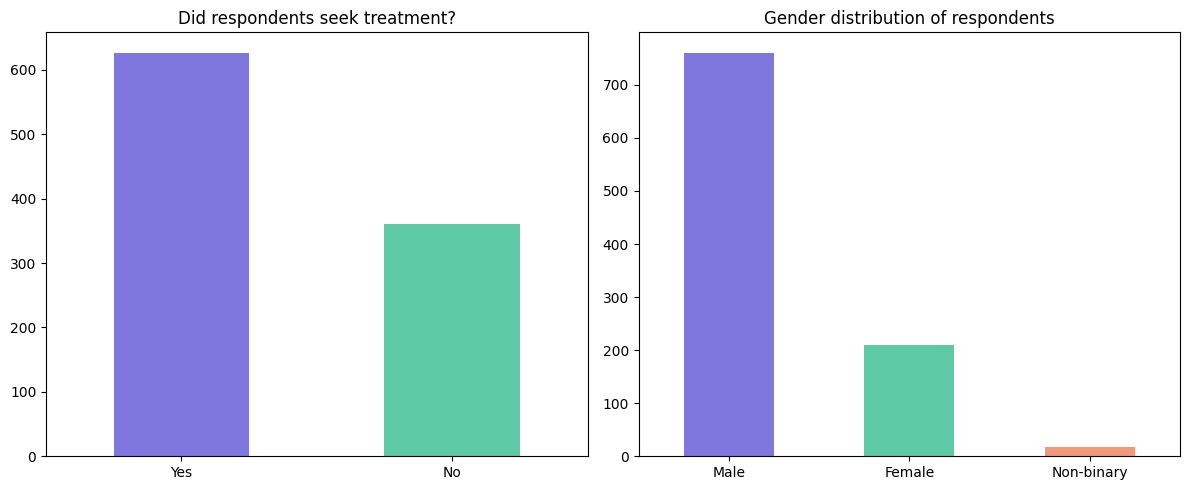

In [28]:

# Chart 1: Treatment seekers
fig, axes = plt.subplots(1, 2, figsize=(12, 5))  # 2 plots side by side

df['treatment'].value_counts().plot(
    kind='bar', ax=axes[0],
    color=['#7F77DD','#5DCAA5'], edgecolor='none'
)
axes[0].set_title('Did respondents seek treatment?')
axes[0].set_xlabel('')
axes[0].set_xticks([0,1])
axes[0].set_xticklabels(['Yes','No'], rotation=0)

# Chart 2: Gender distribution
df['Gender_clean'].value_counts().plot(
    kind='bar', ax=axes[1],
    color=['#7F77DD','#5DCAA5','#F0997B'], edgecolor='none'
)
axes[1].set_title('Gender distribution of respondents')
axes[1].set_xlabel('')
axes[1].tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.savefig('../charts/day2_overview.png', dpi=150, bbox_inches='tight')
plt.show()